<a href="https://colab.research.google.com/github/Thilan67/PlayerTrackingInSports/blob/main/ProgrammingAssignment2_DTS2409.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Sun Oct  5 13:37:43 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Install necessary libraries
!pip install ultralytics roboflow opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.8/89.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 73.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [ ]:
from roboflow import Roboflow
from google.colab import userdata
from IPython.display import Image

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="YSIFTqbRMh2p4suMhysC")
project = rf.workspace("aiwiththilan").project("detectplayers-0hxtm")
version = project.version(3)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to DetectPlayers-3 in yolov8:: 100%|██████████| 310/310 [00:00<00:00, 7520.54it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os
import yaml

# Fix the paths in your data.yaml
yaml_path = f'{dataset.location}/data.yaml'

with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("Before fixing:")
print(f"Train: {data_config['train']}")
print(f"Val: {data_config['val']}")

# Update to correct paths for YOUR dataset
data_config['train'] = f'{dataset.location}/train/images'
data_config['val'] = f'{dataset.location}/valid/images'

# Only include test if the directory exists
test_path = f'{dataset.location}/test/images'
if os.path.exists(test_path):
    data_config['test'] = test_path
elif 'test' in data_config:
    del data_config['test']

# Save the corrected data.yaml
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print("\nAfter fixing:")
print(f"Train: {data_config['train']}")
print(f"Val: {data_config['val']}")
print(f"Test: {data_config.get('test', 'Not included')}")

# Verify the corrected paths exist
print("\n✅ Corrected path verification:")
print(f"Train path exists: {os.path.exists(data_config['train'])}")
print(f"Val path exists: {os.path.exists(data_config['val'])}")

Before fixing:
Train: ../train/images
Val: ../valid/images

After fixing:
Train: /content/DetectPlayers-3/train/images
Val: /content/DetectPlayers-3/valid/images
Test: /content/DetectPlayers-3/test/images

✅ Corrected path verification:
Train path exists: True
Val path exists: True


In [ ]:
%cd {HOME}

# Use smaller model and resolution
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml batch=16 epochs=50 imgsz=640 plots=True

/content
Ultralytics 8.3.205 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/DetectPlayers-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

/content

🎯 Confusion Matrix:


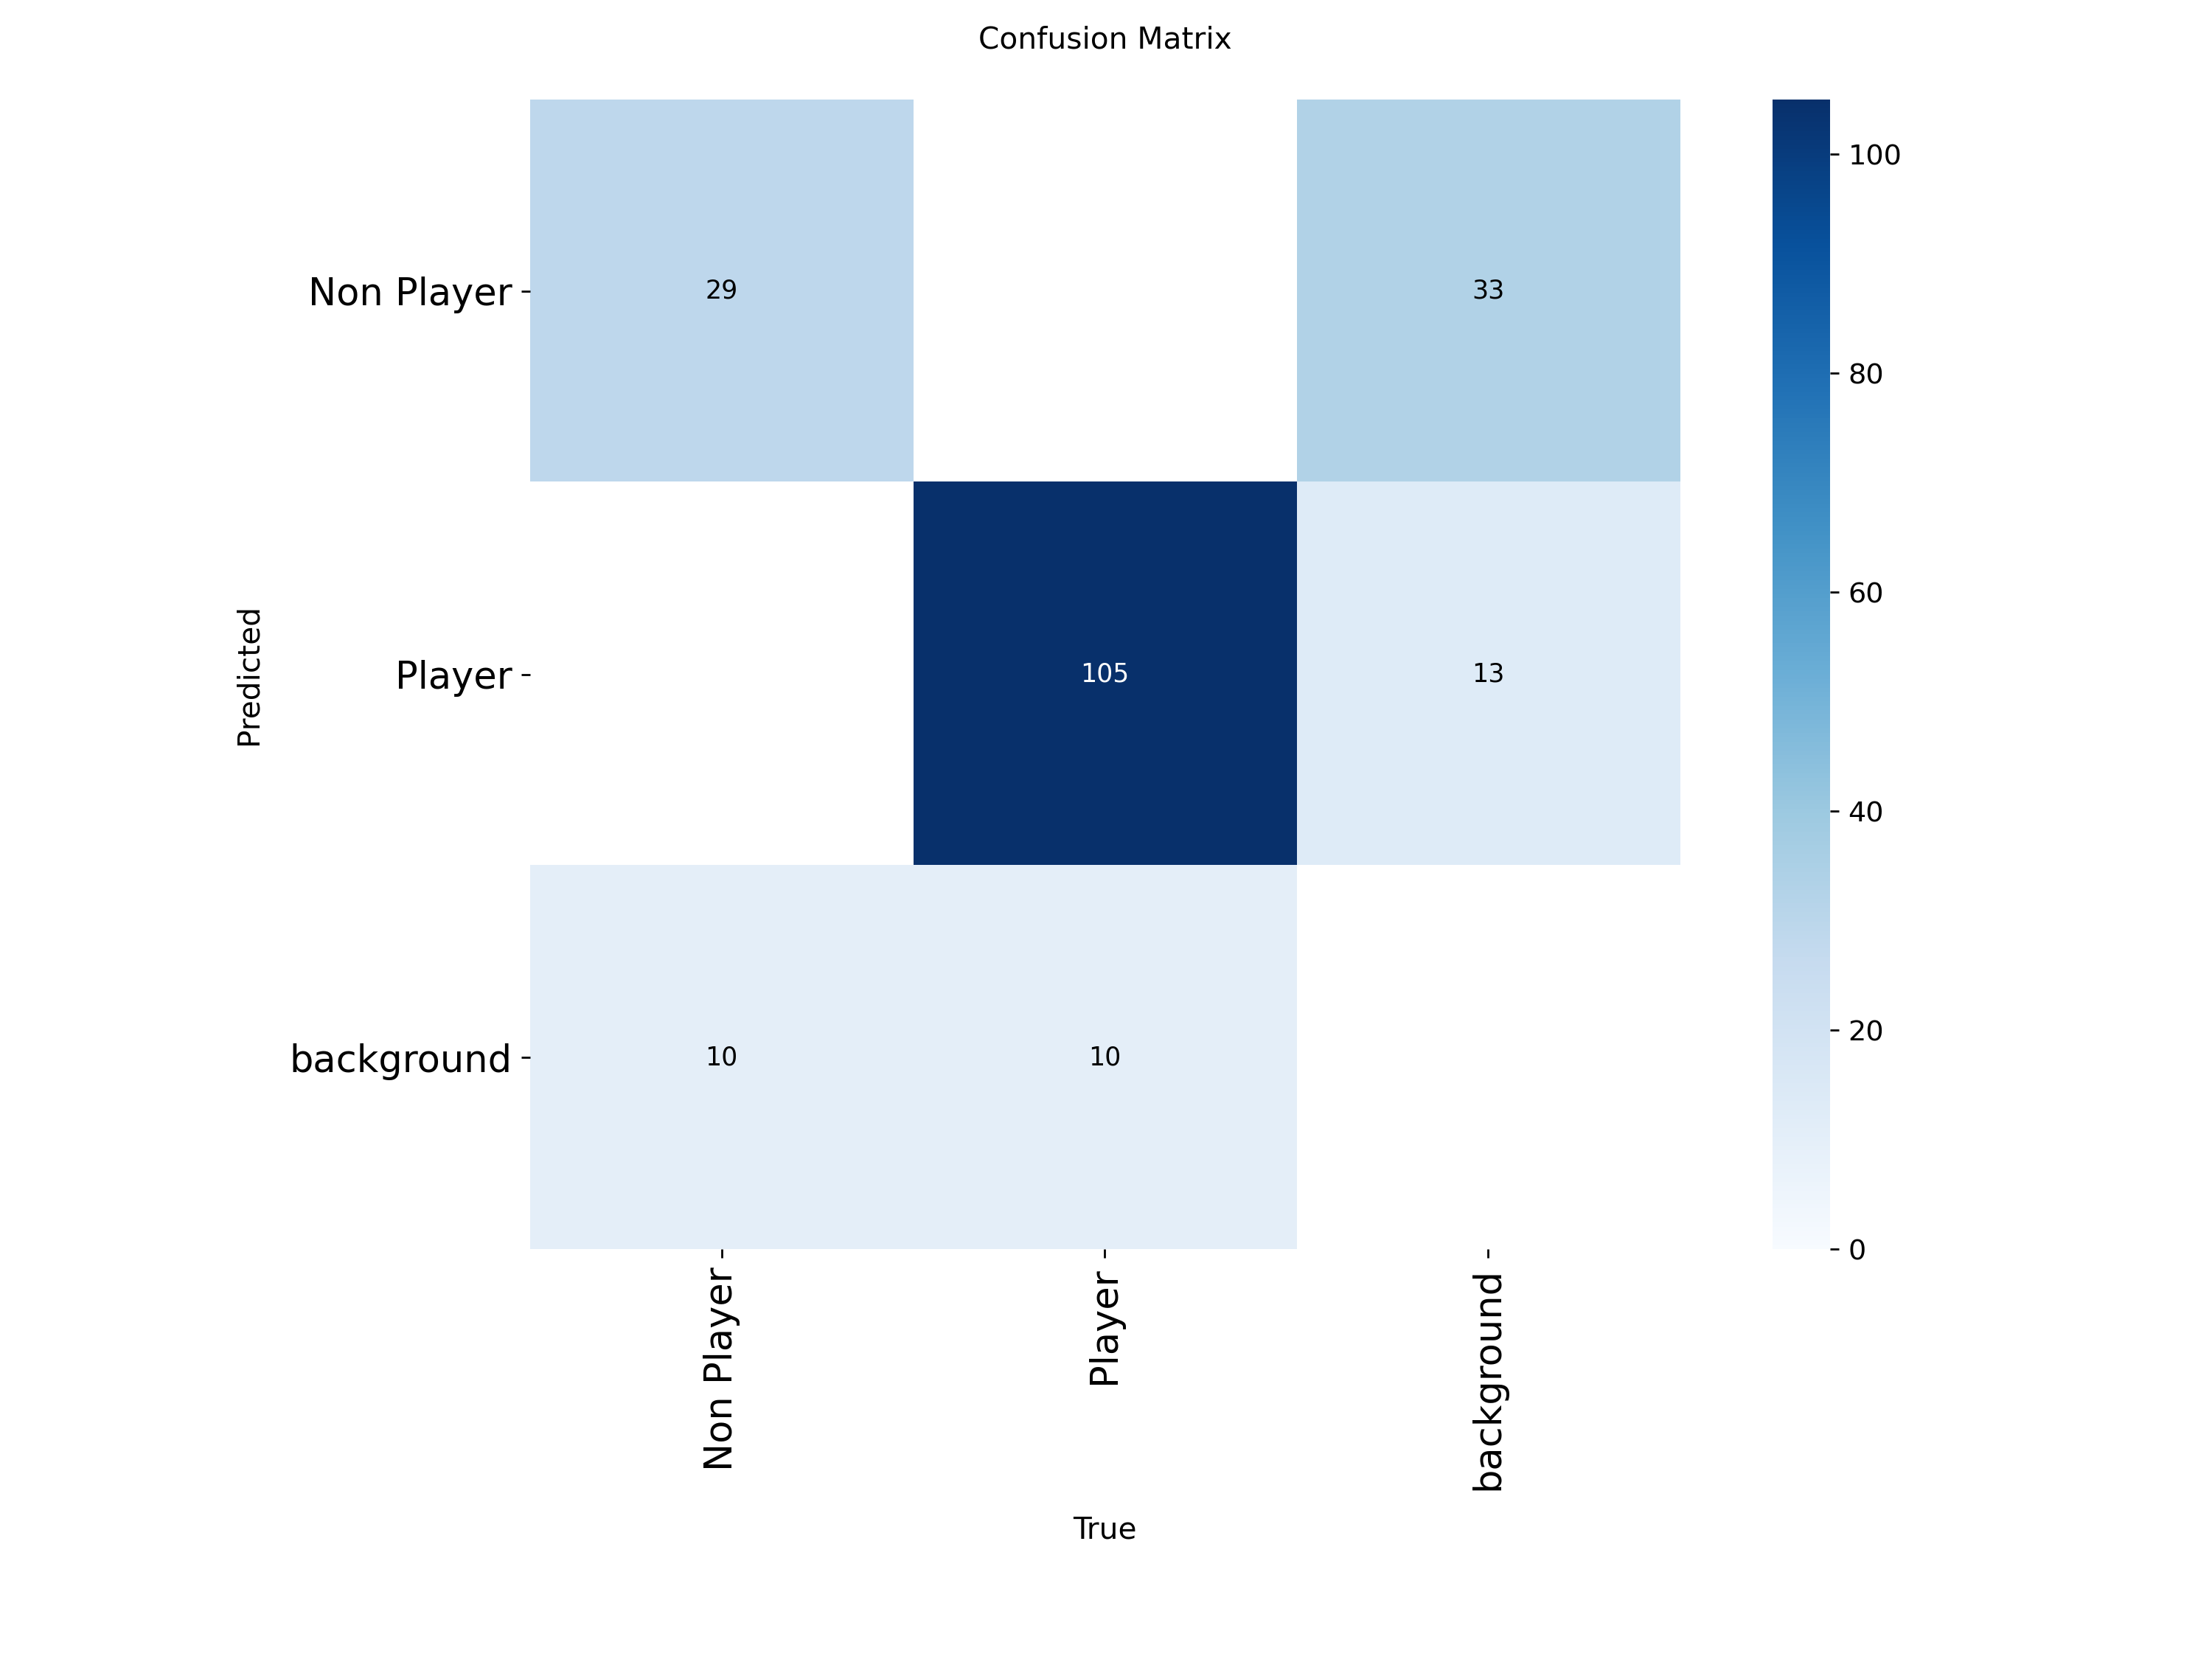


📈 Training Metrics:


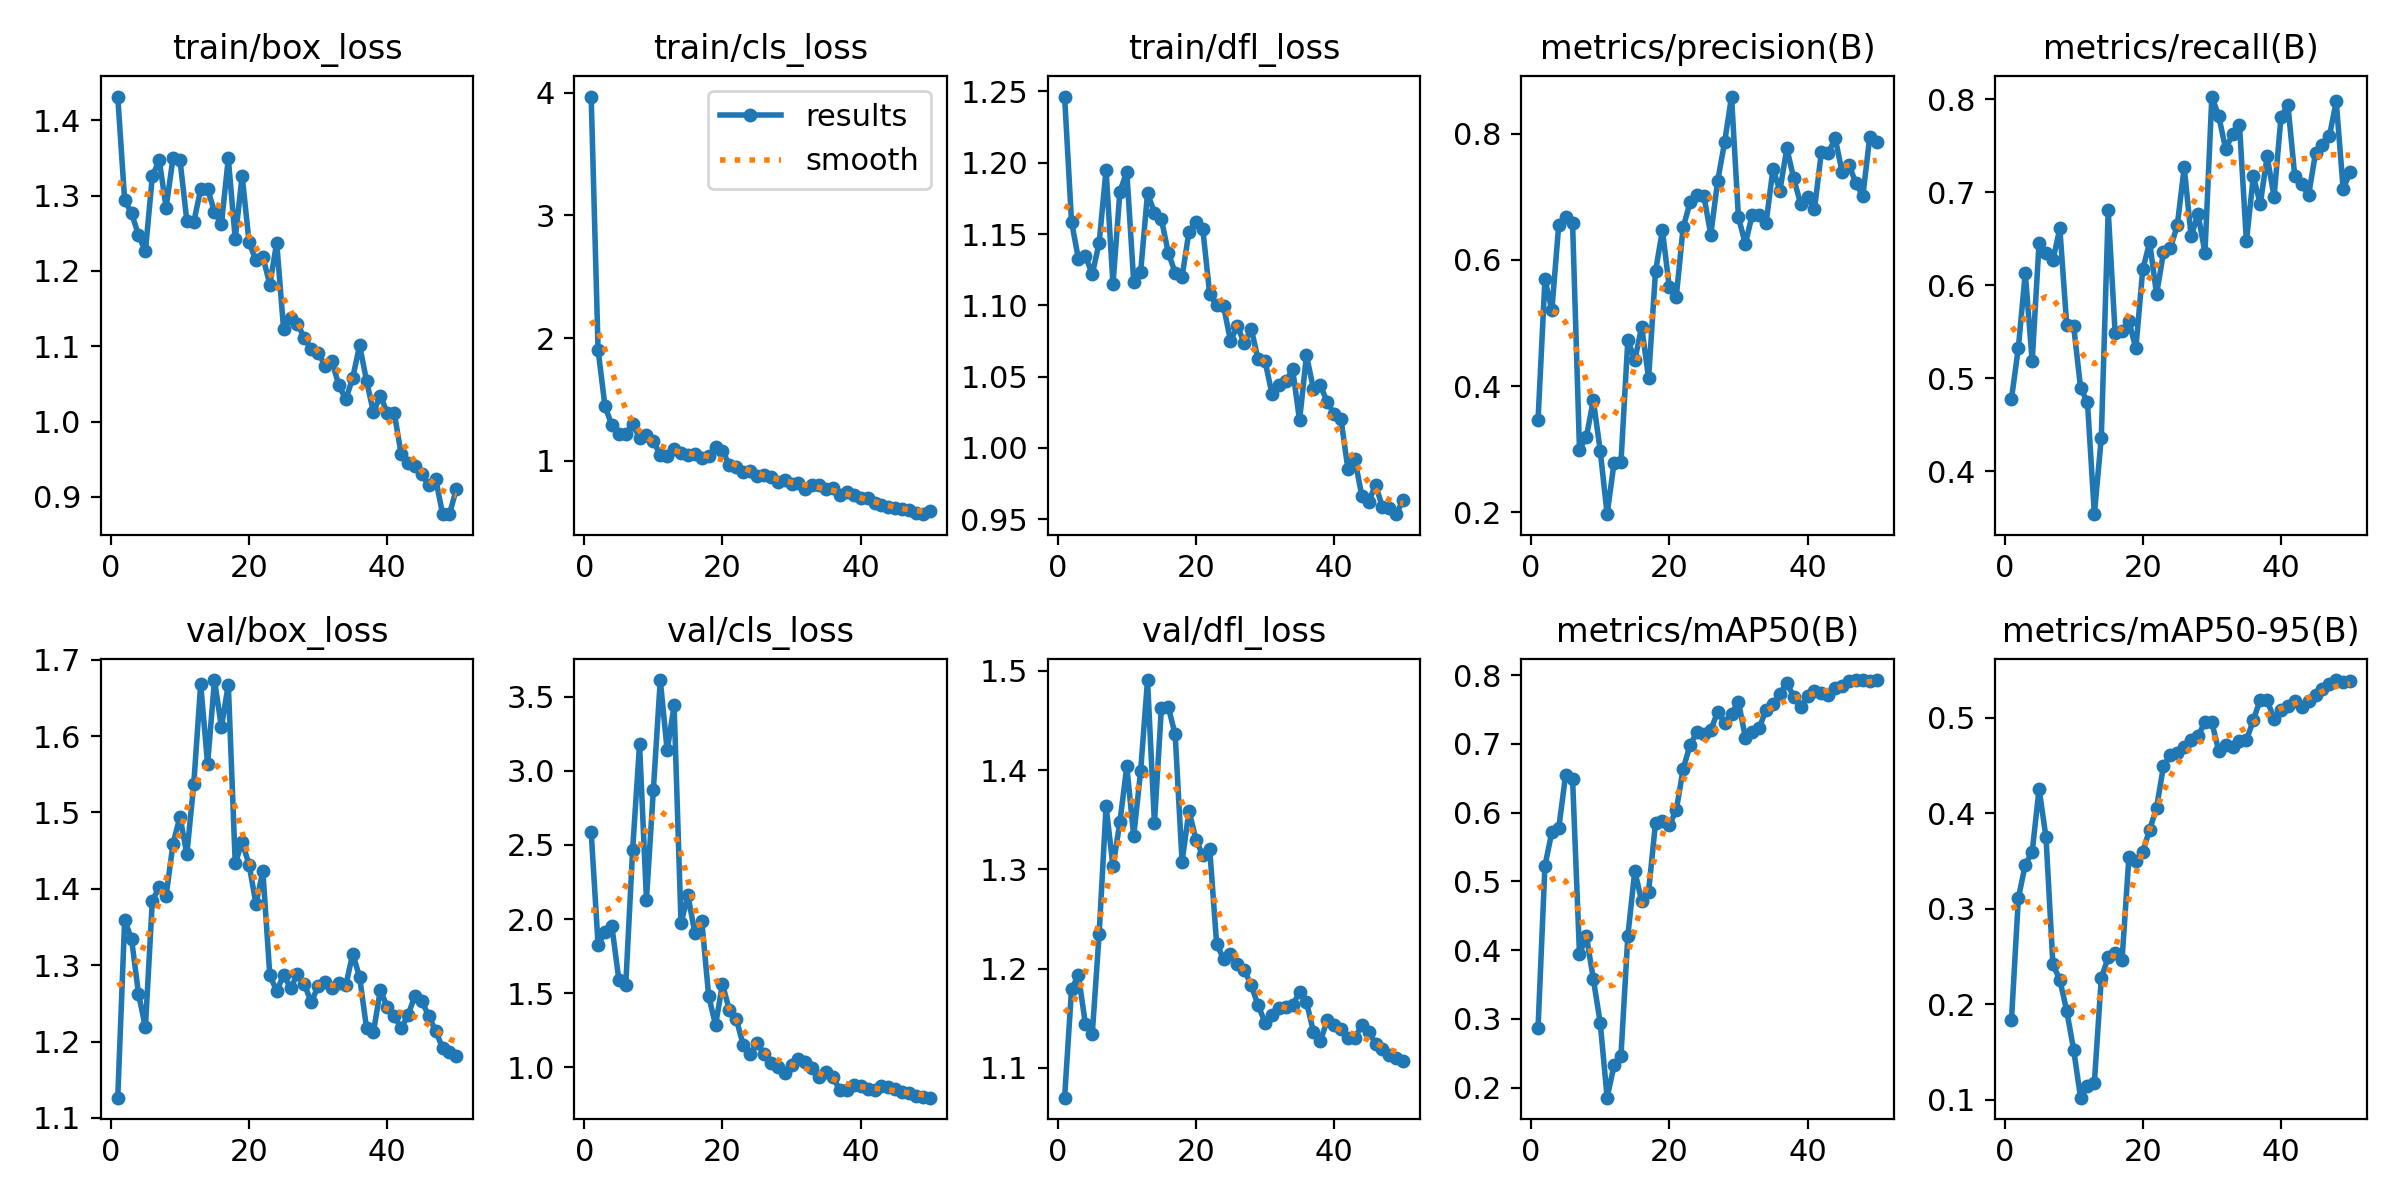


🔍 Sample Predictions:


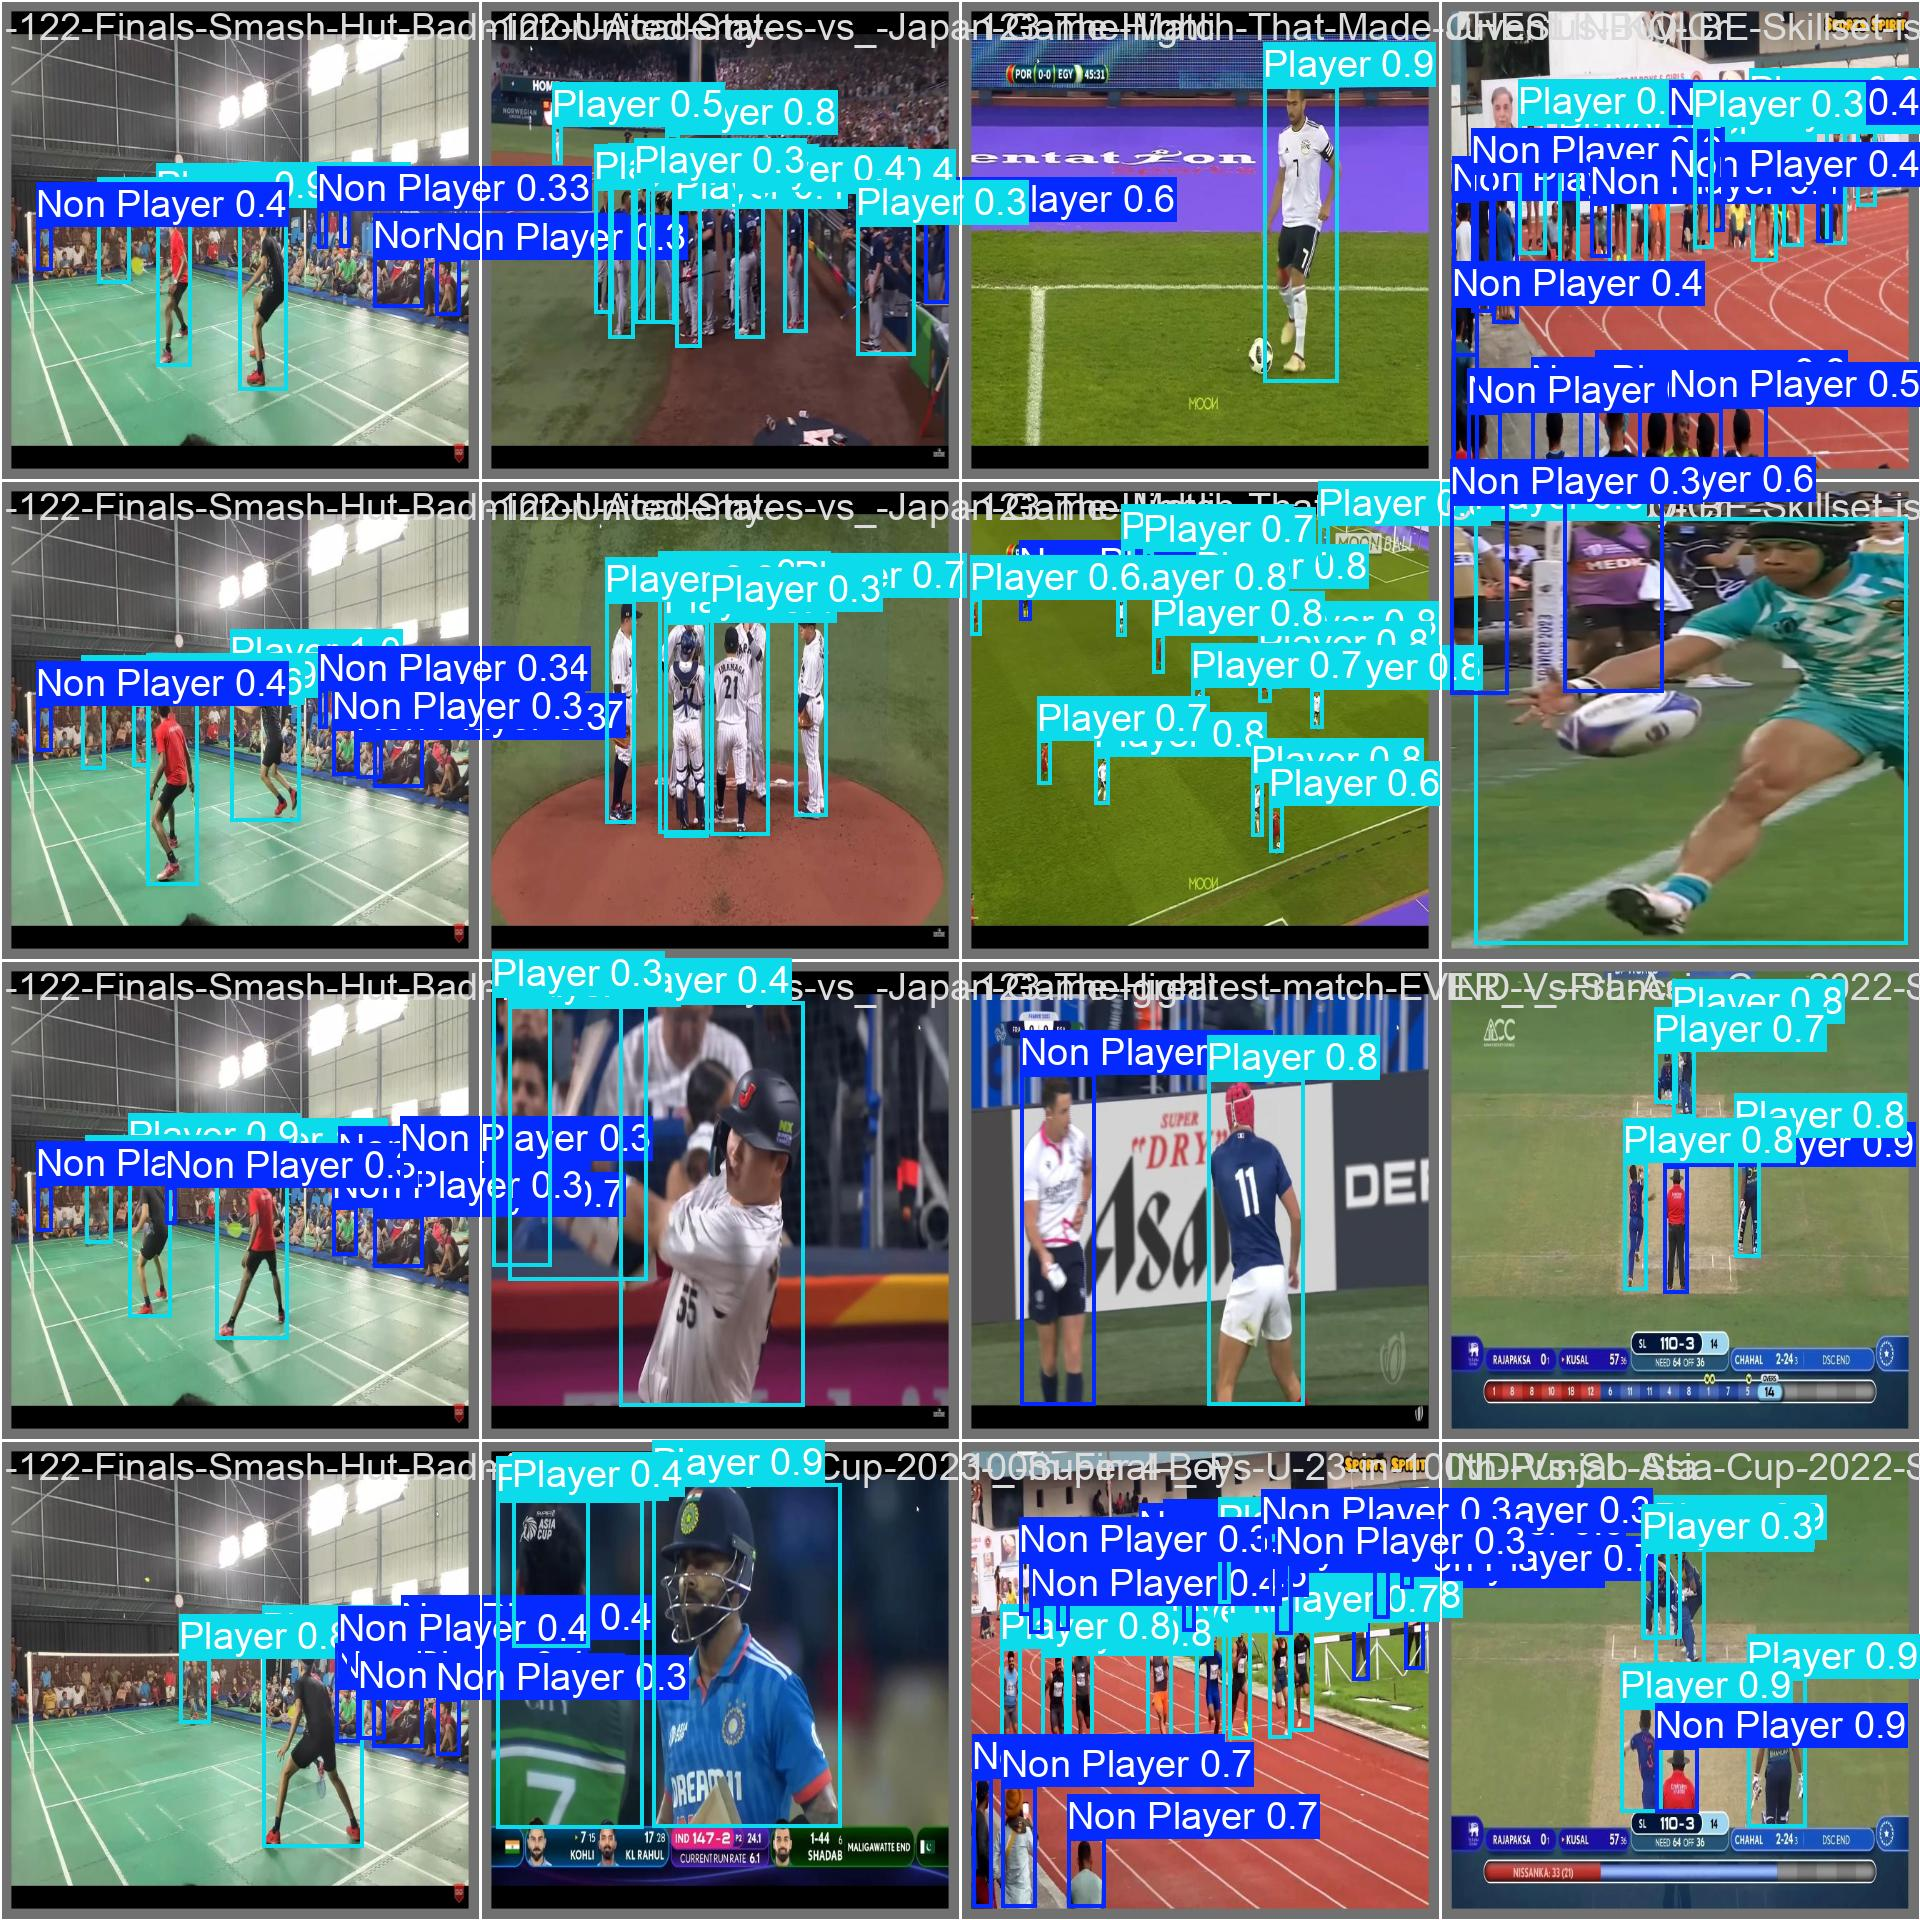


📊 Label Distribution:


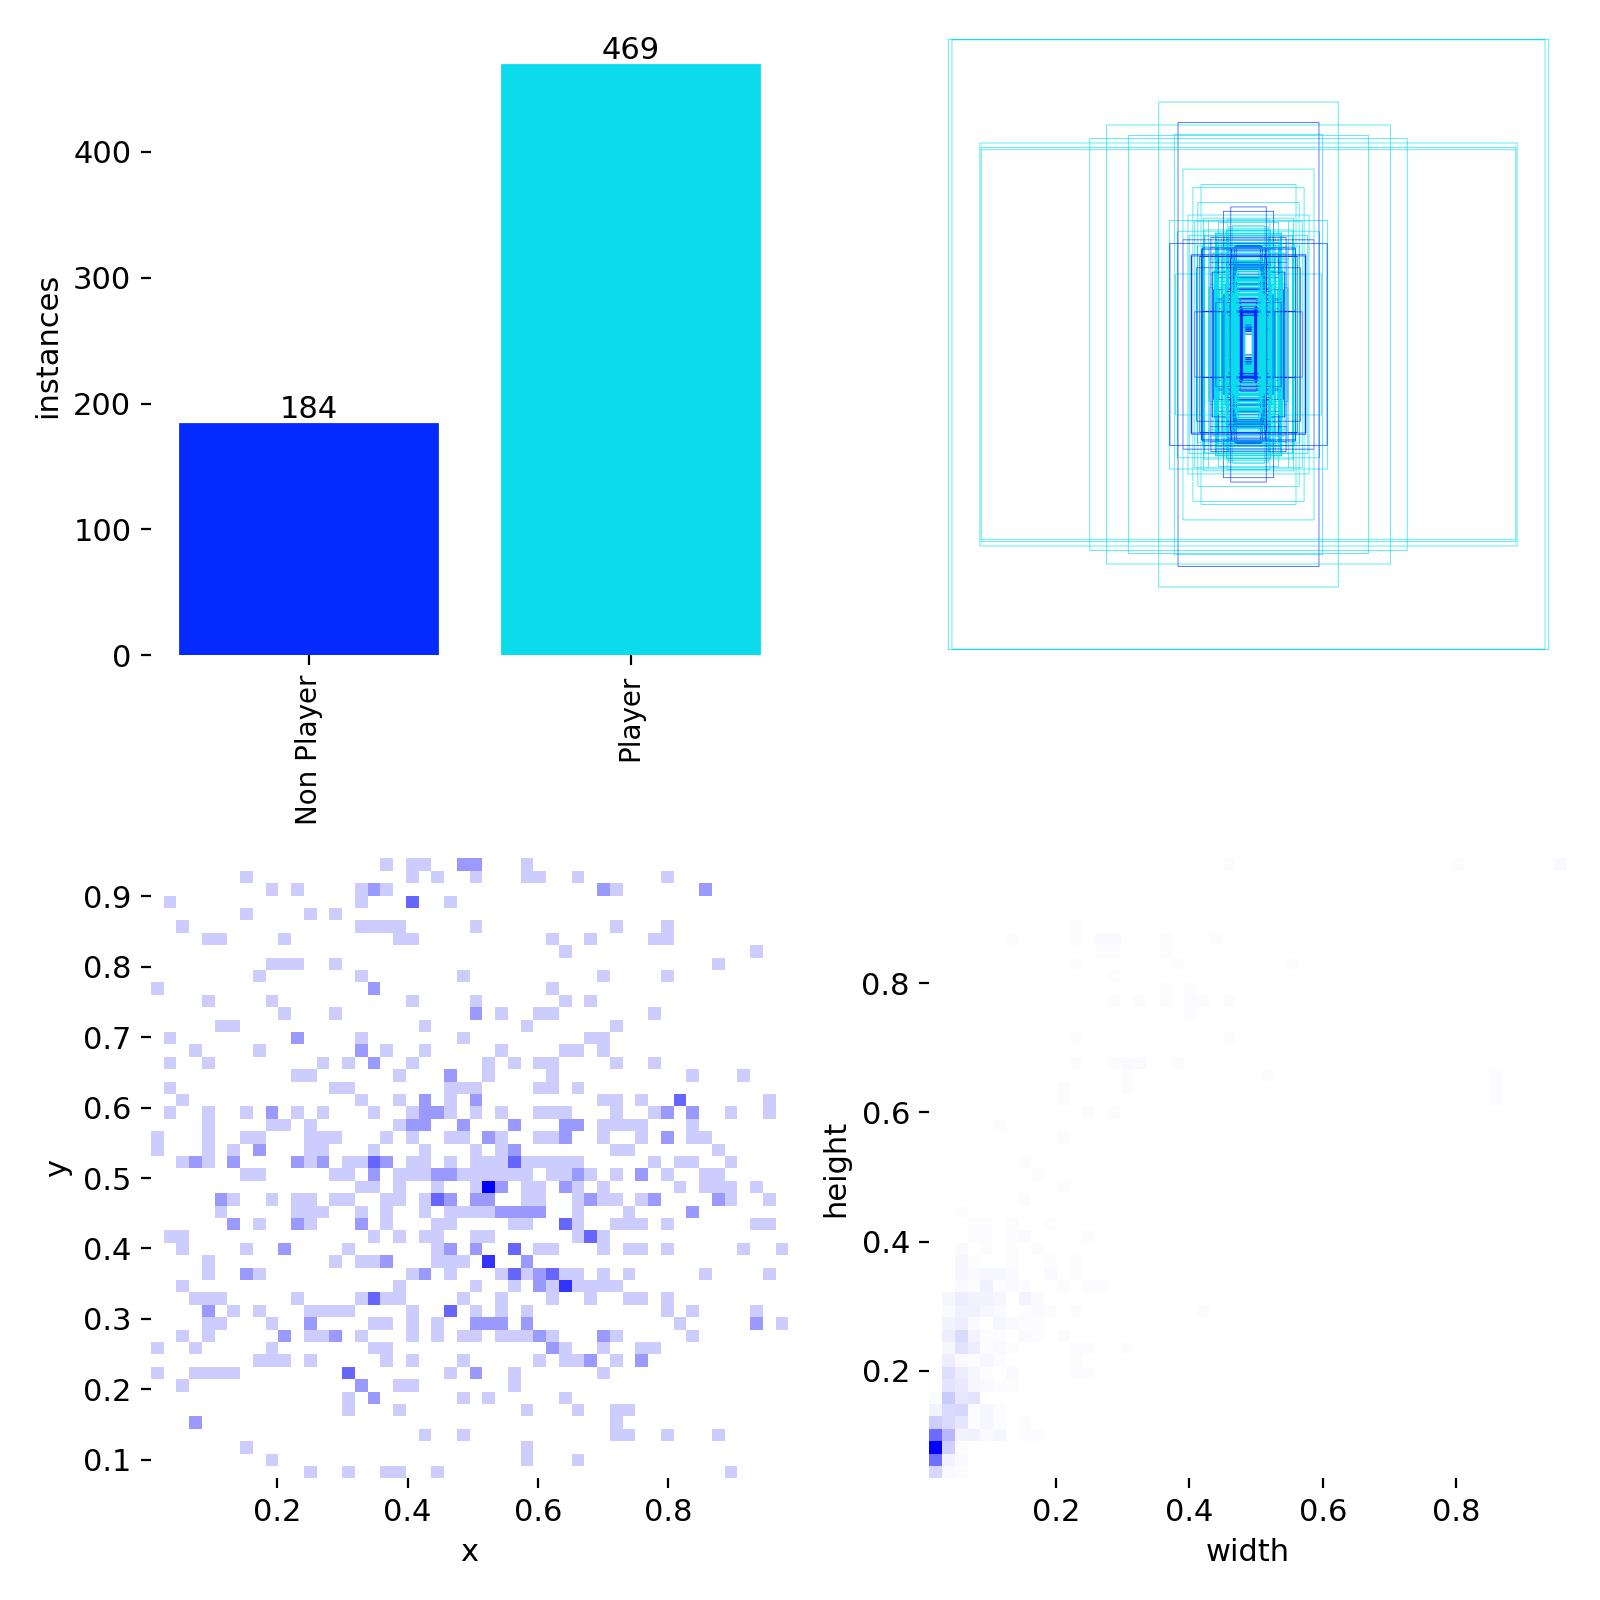

In [ ]:
%cd {HOME}

from IPython.display import Image
import os

# Display all results after training completes
results_files = {
    'confusion_matrix.png': '🎯 Confusion Matrix',
    'results.png': '📈 Training Metrics',
    'val_batch0_pred.jpg': '🔍 Sample Predictions',
    'labels.jpg': '📊 Label Distribution'
}

for file, description in results_files.items():
    file_path = f'runs/detect/train/{file}'
    if os.path.exists(file_path):
        print(f"\n{description}:")
        display(Image(filename=file_path, width=600))
    else:
        print(f"❌ {file} not found yet")

Ultralytics 8.3.205 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

image 1/30 /content/DetectPlayers-3/valid/images/-122-Finals-Smash-Hut-Badminton-Academy-Men-Doubles-Tournament-SIDARTH_T-DHILEPAN-vs-SHIJAS-JAISON-YouTube-Google-Chrome-2025-09-19-12-39-53_mp4-0000_jpg.rf.960bef4e4e824128ccd5b7f5d5831554.jpg: 640x640 1 Non Player, 3 Players, 16.3ms
image 2/30 /content/DetectPlayers-3/valid/images/-122-Finals-Smash-Hut-Badminton-Academy-Men-Doubles-Tournament-SIDARTH_T-DHILEPAN-vs-SHIJAS-JAISON-YouTube-Google-Chrome-2025-09-19-12-39-53_mp4-0001_jpg.rf.86722faa070162ccff63103b800424bb.jpg: 640x640 1 Non Player, 4 Players, 16.2ms
image 3/30 /content/DetectPlayers-3/valid/images/-122-Finals-Smash-Hut-Badminton-Academy-Men-Doubles-Tournament-SIDARTH_T-DHILEPAN-vs-SHIJAS-JAISON-YouTube-Google-Chrome-2025-09-19-12-39-53_mp4-0003_jpg.rf.96fb23f49b68ad5ad8eb40a45c67ef2a.jpg: 640x640 1 Non Player, 

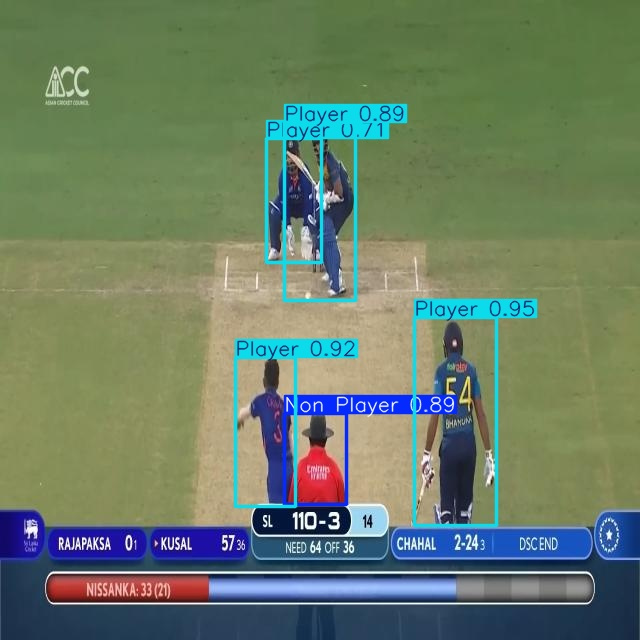

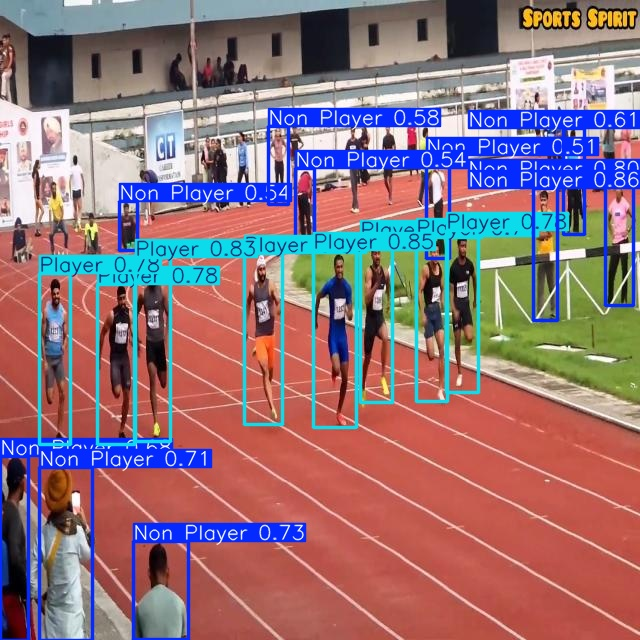

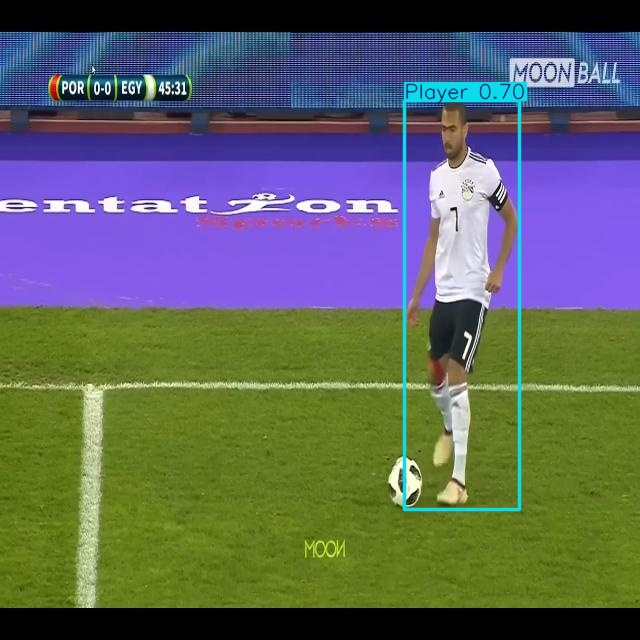

In [ ]:
# Test on validation images
!yolo task=detect mode=predict model=runs/detect/train/weights/best.pt source={dataset.location}/valid/images save=True conf=0.5

# Display predictions
from IPython.display import Image
import glob

print("🔍 Sample Predictions on Validation Set:")
predicted_images = glob.glob('runs/detect/predict*/**.jpg')[:3]
for img_path in predicted_images:
    display(Image(filename=img_path, width=500))

In [ ]:
# Get detailed performance metrics
!yolo task=detect mode=val model=runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.205 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1392.5±446.3 MB/s, size: 43.2 KB)
val: Scanning /content/DetectPlayers-3/valid/labels.cache... 30 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30/30 596.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4it/s 1.4s
                   all         30        154      0.701      0.797      0.795      0.541
            Non Player         14         39      0.497      0.692      0.639      0.443
                Player         30        115      0.904      0.903      0.951      0.639
Speed: 4.9ms preprocess, 20.2ms inference, 0.0ms loss, 4.6ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
from google.colab import files
from IPython.display import Image
import os
import glob

# Upload images
uploaded = files.upload()

# Test on uploaded images
for filename in uploaded.keys():
    !yolo task=detect mode=predict model=runs/detect/train/weights/best.pt source={filename} save=True

    # Find the latest prediction directory
    prediction_dirs = glob.glob('runs/detect/predict*')
    if prediction_dirs:
        latest_predict_dir = sorted(prediction_dirs)[-1]  # Get most recent
        predicted_image_path = f'{latest_predict_dir}/{filename}'

        if os.path.exists(predicted_image_path):
            print(f"✅ Prediction for {filename}:")
            display(Image(filename=predicted_image_path, width=500))
        else:
            print(f"❌ Predicted image not found at: {predicted_image_path}")
            print(f"Files in {latest_predict_dir}:")
            for file in os.listdir(latest_predict_dir)[:5]:  # Show first 5 files
                print(f"  - {file}")
    else:
        print("❌ No prediction directories found")

Saving images.jpeg to images (1).jpeg
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `yolo task=detect mode=predict model=runs/detect/train/weights/best.pt source=images (1).jpeg save=True'
❌ Predicted image not found at: runs/detect/predict2/images (1).jpeg
Files in runs/detect/predict2:
  - images.jpg


In [ ]:
from google.colab import files
from IPython.display import HTML, Video
from base64 import b64encode
import os
import glob

# Upload video
print("📹 Upload your video:")
uploaded = files.upload()

# Get the uploaded filename
original_filename = list(uploaded.keys())[0]
print(f"Original filename: {original_filename}")

# Create a clean filename (remove spaces and special characters)
clean_filename = "cricket_video.mp4"
os.rename(original_filename, clean_filename)
print(f"Clean filename: {clean_filename}")

# Process the video with your model
!yolo task=detect mode=predict model=runs/detect/train/weights/best.pt source={clean_filename} save=True conf=0.5

# Find the processed video
prediction_dirs = glob.glob('runs/detect/predict*')
if prediction_dirs:
    latest_dir = sorted(prediction_dirs)[-1]
    print(f"Looking in: {latest_dir}")

    # Check what files were created
    print("Files in prediction directory:")
    for file in os.listdir(latest_dir):
        print(f"  - {file}")

    # Look for the output video
    video_files = glob.glob(f'{latest_dir}/*.mp4')

    if video_files:
        output_video = video_files[0]
        print(f"🎬 Success! Processed video: {output_video}")

        # Display the video
        display(Video(output_video, width=600))

        print(f"✅ Video saved at: {output_video}")
    else:
        print("❌ No MP4 output found. The video might still be processing or there was an error.")
else:
    print("❌ No prediction directories found")

📹 Upload your video:


Saving (204) Full Highlights _ Afghanistan vs Bangladesh _ Match 02 _ T20I Series _ ACB _ 311K - YouTube - Google Chrome 2025-10-05 19-35-58.mp4 to (204) Full Highlights _ Afghanistan vs Bangladesh _ Match 02 _ T20I Series _ ACB _ 311K - YouTube - Google Chrome 2025-10-05 19-35-58.mp4
Original filename: (204) Full Highlights _ Afghanistan vs Bangladesh _ Match 02 _ T20I Series _ ACB _ 311K - YouTube - Google Chrome 2025-10-05 19-35-58.mp4
Clean filename: cricket_video.mp4
Ultralytics 8.3.205 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs

video 1/1 (frame 1/407) /content/cricket_video.mp4: 416x640 1 Non Player, 1 Player, 43.0ms
video 1/1 (frame 2/407) /content/cricket_video.mp4: 416x640 2 Non Players, 2 Players, 12.7ms
video 1/1 (frame 3/407) /content/cricket_video.mp4: 416x640 2 Non Players, 1 Player, 12.7ms
video 1/1 (frame 4/407) /content/cricket_video.mp4: 416x640 1 Non Player, 1 Playe

In [ ]:
from ultralytics import YOLO

# Uses COCO pre-trained keypoints (17 points: nose, eyes, shoulders, elbows, wrists, hips, knees, ankles)
model = YOLO('yolov8n-pose.pt')  # Already trained on COCO dataset

# Ready to use immediately - no annotation needed!
results = model('/content/images.jpeg')

for result in results:
   result.save('output.jpg')


image 1/1 /content/images.jpeg: 448x640 6 persons, 198.2ms
Speed: 5.3ms preprocess, 198.2ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)
